# Taller de limpieza de datos con Python y Pandas
Primer taller del curso de MLops realizado con el objectivo de aprender a identificar y corregir datos sucios (valores faltantes, duplicados, inconsistencias, tipos
incorrectos) usando pandas en Python, aplicando diferentes técnicas de limpieza en datasets
reales.

# Dataset 1: Iris Sucio
El dataset Iris Sucio contiene flores Iris, pero con problemas:
    - Valores faltantes (NA) en las columnas númericas.
    - Especies escritas con inconsistencias: Setosa, setosa, SETOSA.


### Cargando librerias

In [103]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

print('Matplotlib configurado correctamente para Jupyter.')

Matplotlib configurado correctamente para Jupyter.


In [104]:
import numpy as np

In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as Sns

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

print("Librerias importadas.")

Librerias importadas.


## Cargar CSV
Se utiliza pandas para cargar el dataset y se muestran las primeras filas del dataframe creado, con sus tipos de datos. 

In [106]:
file_path = 'iris_dirty.csv'

df = pd.read_csv(file_path)

from IPython.display import display

display(df.head())

print('Dimensiones (filas, columnas): ', df.shape)
print('Tipos de datos por columna: ')


print(df.dtypes)

,Unnamed: 0,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,1,5.1,3.5,1.4,0.2,Setosa
1,2,4.9,3.0,1.4,0.2,setosa
2,3,4.7,3.2,1.3,0.2,setosa
3,4,4.6,3.1,1.5,0.2,setosa
4,5,NaN,3.6,1.4,0.2,setosa


Dimensiones (filas, columnas):  (150, 6)
Tipos de datos por columna: 
Unnamed: 0        int64
Sepal.Length    float64
Sepal.Width     float64
Petal.Length    float64
Petal.Width     float64
Species          object
dtype: object


Para conocer la información del dataframe, como columnas, cantidad de datos no nulos y tipos usamos .info(). Además, para calcular la media, mediana, la desviación estandar, minimos, maximos, etc; utilizamos .describe().

In [107]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    150 non-null    int64  
 1   Sepal.Length  142 non-null    float64
 2   Sepal.Width   139 non-null    float64
 3   Petal.Length  150 non-null    float64
 4   Petal.Width   150 non-null    float64
 5   Species       150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


,Unnamed: 0,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
count,150.000000,142.000000,139.000000,150.000000,150.000000
mean,75.500000,5.840141,3.043165,3.758000,1.199333
std,43.445368,0.831905,0.438550,1.765298,0.762238
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


## Normalización, Detección y manejo valores nulos
Para conocer qué columnas tienen valores faltantes o valores nulos y cuantos, utilizamos la funcion .isna().sum(). Por otro lado, para conocer los tipos de datos de las columnas en donde se encuentra valores faltantes utilizamos .dtypes.

In [108]:
faltantes = df.isna().sum()
print('Valores faltantes por columna: ', faltantes)

print('Tipos de datos originales: ')
print(df.dtypes)

print('Tipos de datos faltantes: ')
print(faltantes.dtypes)

Valores faltantes por columna:  Unnamed: 0       0
Sepal.Length     8
Sepal.Width     11
Petal.Length     0
Petal.Width      0
Species          0
dtype: int64
Tipos de datos originales: 
Unnamed: 0        int64
Sepal.Length    float64
Sepal.Width     float64
Petal.Length    float64
Petal.Width     float64
Species          object
dtype: object
Tipos de datos faltantes: 
int64


#### Para conocer cuales son los valores que contiene la variable categorica, se utiliza la función de .unique() de pandas en el dataframe.

In [109]:
df["Species"].unique()

array(['Setosa', 'setosa', 'SETOSA', 'versicolor', 'Versicolor',
       'VERSICOLOR', 'virginica', 'VIRGINICA'], dtype=object)

En este caso, podemos observar que tenemos los mismos tres valores en la columna Species pero se diferencian en la nomenclatura, por ello, se ponen todos los valores en minusculas. Luego, se cambian a que la primera letra del valor en todos los casos sea mayuscula. 

In [110]:
df_clean = df.copy()

df_clean['Species'] = df_clean['Species'].str.lower()

df_clean['Species']= df_clean['Species'].map({
    "setosa": "Setosa",
    "versicolor": "Versicolor",
    "virginica": "Virginica"
})

print(df_clean)

     Unnamed: 0  Sepal.Length  Sepal.Width  Petal.Length  Petal.Width  \
0             1           5.1          3.5           1.4          0.2   
1             2           4.9          3.0           1.4          0.2   
2             3           4.7          3.2           1.3          0.2   
3             4           4.6          3.1           1.5          0.2   
4             5           NaN          3.6           1.4          0.2   
..          ...           ...          ...           ...          ...   
145         146           6.7          3.0           5.2          2.3   
146         147           6.3          2.5           5.0          1.9   
147         148           6.5          3.0           5.2          2.0   
148         149           6.2          3.4           5.4          2.3   
149         150           NaN          3.0           5.1          1.8   

       Species  
0       Setosa  
1       Setosa  
2       Setosa  
3       Setosa  
4       Setosa  
..         ...  
145 

### Lo que hacemos ahora es convertir las variables categoricas a númericas.

In [111]:
map_species = {'Setosa': 1,'Versicolor':2, 'Virginica':3}

df_clean['Species_new'] = df_clean['Species'].map(map_species)
print(df_clean)

     Unnamed: 0  Sepal.Length  Sepal.Width  Petal.Length  Petal.Width  \
0             1           5.1          3.5           1.4          0.2   
1             2           4.9          3.0           1.4          0.2   
2             3           4.7          3.2           1.3          0.2   
3             4           4.6          3.1           1.5          0.2   
4             5           NaN          3.6           1.4          0.2   
..          ...           ...          ...           ...          ...   
145         146           6.7          3.0           5.2          2.3   
146         147           6.3          2.5           5.0          1.9   
147         148           6.5          3.0           5.2          2.0   
148         149           6.2          3.4           5.4          2.3   
149         150           NaN          3.0           5.1          1.8   

       Species  Species_new  
0       Setosa            1  
1       Setosa            1  
2       Setosa            1  
3  

In [112]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    150 non-null    int64  
 1   Sepal.Length  142 non-null    float64
 2   Sepal.Width   139 non-null    float64
 3   Petal.Length  150 non-null    float64
 4   Petal.Width   150 non-null    float64
 5   Species       150 non-null    object 
 6   Species_new   150 non-null    int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 8.3+ KB


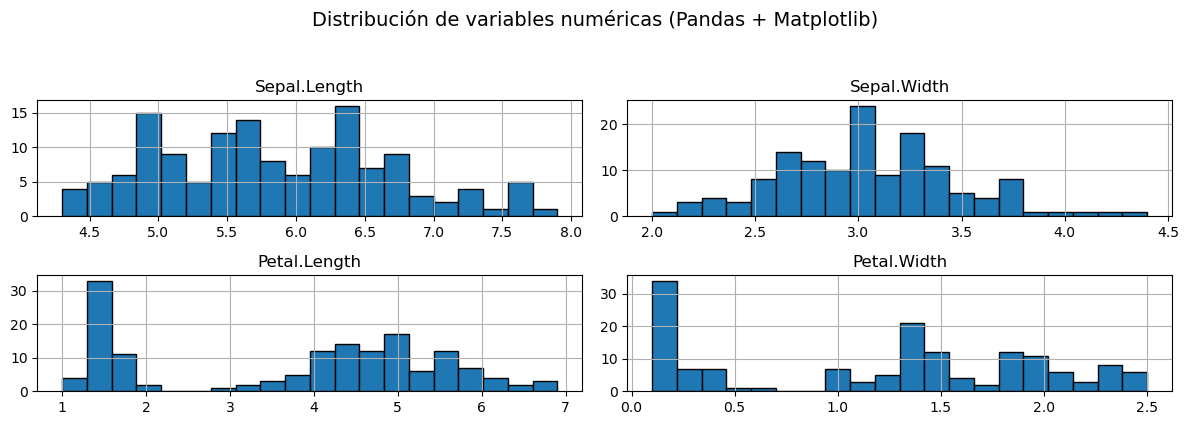

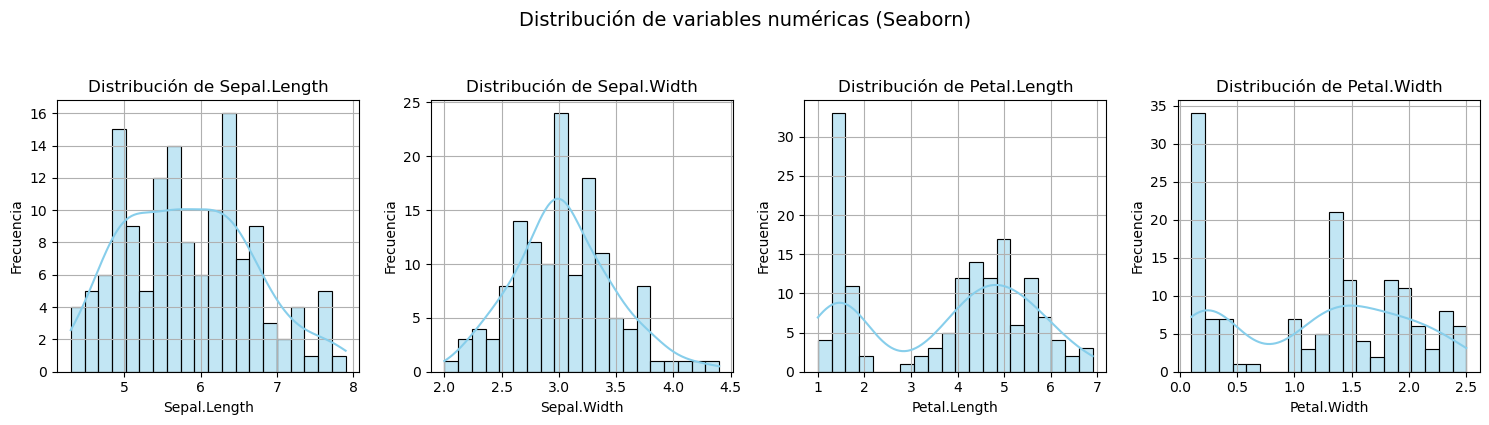

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['Sepal.Length', 'Sepal.Width', 'Petal.Length', 'Petal.Width']

df_clean[num_cols].hist(bins=20, figsize=(12, 4), edgecolor='black')
plt.suptitle('Distribución de variables numéricas (Pandas + Matplotlib)', y=1.05, fontsize=14)
plt.tight_layout()
plt.show()

# --- Opción 2: usando Seaborn para más estilo ---
fig, axes = plt.subplots(1, len(num_cols), figsize=(15,4))

for i, col in enumerate(num_cols):
    sns.histplot(data=df_clean, x=col, bins=20, kde=True, ax=axes[i], color="skyblue")
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de variables numéricas (Seaborn)', y=1.05, fontsize=14)
plt.tight_layout()
plt.show()


In [114]:
df_clean["Sepal.Length"] = df_clean["Sepal.Length"].fillna(df_clean["Sepal.Length"].mean())


In [115]:
df_clean["Sepal.Width"] = df_clean["Sepal.Width"].fillna(df_clean["Sepal.Width"].median())


In [116]:
faltantes_clean = df_clean.isna().sum()
print('Valores faltantes por columna: ', faltantes_clean)

Valores faltantes por columna:  Unnamed: 0      0
Sepal.Length    0
Sepal.Width     0
Petal.Length    0
Petal.Width     0
Species         0
Species_new     0
dtype: int64


## Manejo de valores duplicados

In [119]:
duplicados = df_clean.duplicated('Sepal.Length').sum()
print('Valores duplicados por columna:', duplicados)



Valores duplicados por columna: 114


# Dataset 2: Adult Census Income

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('Librerías importadas correctamente.')

Librerías importadas correctamente.


## Cargar CSV

In [2]:
file_path_adult = 'adult.data.csv'

df_adult = pd.read_csv(file_path_adult)

from IPython.display import display

display(df_adult.head())

# Mostramos el número de filas y columnas y los tipos de datos por columna
print('Dimensiones (filas, columnas):', df_adult.shape)
print('Tipos de datos por columna:')
print(df_adult.dtypes)

,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


Dimensiones (filas, columnas): (32560, 15)
Tipos de datos por columna:
39                 int64
 State-gov        object
 77516             int64
 Bachelors        object
 13                int64
 Never-married    object
 Adm-clerical     object
 Not-in-family    object
 White            object
 Male             object
 2174              int64
 0                 int64
 40                int64
 United-States    object
 <=50K            object
dtype: object


In [3]:
df_adult.info()
df_adult.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32560 entries, 0 to 32559
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   39              32560 non-null  int64 
 1    State-gov      32560 non-null  object
 2    77516          32560 non-null  int64 
 3    Bachelors      32560 non-null  object
 4    13             32560 non-null  int64 
 5    Never-married  32560 non-null  object
 6    Adm-clerical   32560 non-null  object
 7    Not-in-family  32560 non-null  object
 8    White          32560 non-null  object
 9    Male           32560 non-null  object
 10   2174           32560 non-null  int64 
 11   0              32560 non-null  int64 
 12   40             32560 non-null  int64 
 13   United-States  32560 non-null  object
 14   <=50K          32560 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


,39,77516,13,2174,0,40
count,32560.000000,3.256000e+04,32560.000000,32560.000000,32560.000000,32560.000000
mean,38.581634,1.897818e+05,10.080590,1077.615172,87.306511,40.437469
std,13.640642,1.055498e+05,2.572709,7385.402999,402.966116,12.347618
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178315e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783630e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370545e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [4]:
df_adult.columns = ["age", "workclass", "fnlwgt", "education", "education-num", "marital-status", "occupation", "relationship", "race", "sex", "capital-gain", 
              "capital-loss", "hours-per-week", "native-country", "income"
]

In [5]:
df_adult.info()
df_adult.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32560 entries, 0 to 32559
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32560 non-null  int64 
 1   workclass       32560 non-null  object
 2   fnlwgt          32560 non-null  int64 
 3   education       32560 non-null  object
 4   education-num   32560 non-null  int64 
 5   marital-status  32560 non-null  object
 6   occupation      32560 non-null  object
 7   relationship    32560 non-null  object
 8   race            32560 non-null  object
 9   sex             32560 non-null  object
 10  capital-gain    32560 non-null  int64 
 11  capital-loss    32560 non-null  int64 
 12  hours-per-week  32560 non-null  int64 
 13  native-country  32560 non-null  object
 14  income          32560 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


In [6]:
df_adult_clean = df_adult.copy()

# Lista de columnas que deberían ser numéricas
numeric_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

# Convertimos cada una a numérico; los errores se convertirán en NaN
for col in numeric_cols:
    df_adult_clean[col] = pd.to_numeric(df_adult_clean[col], errors='coerce')

# Mostramos estadísticas descriptivas de las columnas numéricas convertidas
print(df_adult_clean[numeric_cols].describe())

                age        fnlwgt  education-num  capital-gain  capital-loss  \
count  32560.000000  3.256000e+04   32560.000000  32560.000000  32560.000000   
mean      38.581634  1.897818e+05      10.080590   1077.615172     87.306511   
std       13.640642  1.055498e+05       2.572709   7385.402999    402.966116   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178315e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783630e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.370545e+05      12.000000      0.000000      0.000000   
max       90.000000  1.484705e+06      16.000000  99999.000000   4356.000000   

       hours-per-week  
count    32560.000000  
mean        40.437469  
std         12.347618  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  


## Detección y manejo de valores faltantes o nulos.

In [7]:
faltantes_adult = df_adult_clean.isna().sum()
print('Valores faltantes por columna: ', faltantes_adult)

print('Tipos de datos originales:')
print(df_adult.dtypes)

Valores faltantes por columna:  age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64
Tipos de datos originales:
age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object


Normalización

Verificación y normalización de columnas categóricas
Es importante verificar si las columnas categóricas tienen anomalías y normalizarlas si es necesario.
¿Por qué normalizar?
Porque valores como 'Private', 'private', ' Private' y 'PRIVATE' son el mismo concepto pero al si se aplica una transformacion como OneHotEncoder los tratará como categorías diferentes, creando columnas innecesarias y confundiendo al modelo.

In [8]:
categorical_cols = ['workclass', 'education', 'marital-status', 'occupation', 
                   'relationship', 'race', 'sex', 'native-country']

print("=== VERIFICACIÓN RÁPIDA ===")
print("Columna | Únicos | Espacios | Mayús/Min")
print("-" * 45)

for col in categorical_cols:
    valores = df_adult_clean[col].dropna()
    
    unicos = len(valores.unique())
    con_espacios = sum(1 for val in valores.unique() if val != val.strip())
    
    # Verificar si hay duplicados por case sensitivity
    valores_lower = valores.str.lower().str.strip()
    unicos_norm = len(valores_lower.unique())
    case_problems = unicos - unicos_norm
    
    print(f"{col:<15} | {unicos:>5} | {con_espacios:>5} | {case_problems:>5}")

=== VERIFICACIÓN RÁPIDA ===
Columna | Únicos | Espacios | Mayús/Min
---------------------------------------------
workclass       |     9 |     9 |     0
education       |    16 |    16 |     0
marital-status  |     7 |     7 |     0
occupation      |    15 |    15 |     0
relationship    |     6 |     6 |     0
race            |     5 |     5 |     0
sex             |     2 |     2 |     0
native-country  |    42 |    42 |     0


Normalizamos las categorias

In [9]:
#Normalización de categorías
print("\n=== Normalizando categorias ===")
for col in categorical_cols:
    # Normalizar (solo valores no-NaN)
    df_adult_clean[col] = (df_adult_clean[col]
                          .str.strip()
                          .str.lower()
                          .str.replace(r'\s+', ' ', regex=True))
print("\n=== Normalización completada ===")


=== Normalizando categorias ===

=== Normalización completada ===


Verificamos nuevamente como han quedado las columnas despues de la normalizacion

In [10]:
print("=== VERIFICACIÓN RÁPIDA ===")
print("Columna | Únicos | Espacios | Mayús/Min")
print("-" * 45)

for col in categorical_cols:
    valores = df_adult_clean[col].dropna()
    
    unicos = len(valores.unique())
    con_espacios = sum(1 for val in valores.unique() if val != val.strip())
    
    # Verificar si hay duplicados por case sensitivity
    valores_lower = valores.str.lower().str.strip()
    unicos_norm = len(valores_lower.unique())
    case_problems = unicos - unicos_norm
    
    print(f"{col:<15} | {unicos:>5} | {con_espacios:>5} | {case_problems:>5}")

=== VERIFICACIÓN RÁPIDA ===
Columna | Únicos | Espacios | Mayús/Min
---------------------------------------------
workclass       |     9 |     0 |     0
education       |    16 |     0 |     0
marital-status  |     7 |     0 |     0
occupation      |    15 |     0 |     0
relationship    |     6 |     0 |     0
race            |     5 |     0 |     0
sex             |     2 |     0 |     0
native-country  |    42 |     0 |     0


## Valores nulos en columnas categoricas

Limpiar los espacios en blancos está de mas porque eso se hizo en la normalizacion de categorias

In [11]:
# Lista de columnas categóricas a limpiar
#categorical_cols = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']

# Primero limpiamos espacios en blanco y luego reemplazamos '?' por NaN
for col in categorical_cols:
    # Eliminamos espacios al inicio y final, luego reemplazamos '?' por NaN
    df_adult_clean[col] = df_adult_clean[col].str.strip().replace('?', np.nan)

# Mostramos cuántos valores faltantes hay después de la limpieza
for col in categorical_cols:
    print(f"{col}: {df_adult_clean[col].isna().sum()} valores NaN")

workclass: 1836 valores NaN
education: 0 valores NaN
marital-status: 0 valores NaN
occupation: 1843 valores NaN
relationship: 0 valores NaN
race: 0 valores NaN
sex: 0 valores NaN
native-country: 583 valores NaN


Imputar filas, si la fila tiene NaN en algunas de sus columnas no aportara informacion completa al modelo, por lo que se atribuira el el valor de la moda de toda la columna a fila. Por cada columna se cuentan los NaN a reemplazar, se calcula la moda y se llena la fila(.fillna())con ese valor.

In [12]:

print("=== Reemplazo de NaN con moda por columna ===")

# Procesar cada columna
for col in categorical_cols:
    # Contar NaN antes del reemplazo
    nan_antes = df_adult_clean[col].isna().sum()
    
    if nan_antes > 0:  # Solo procesar si hay NaN
        # Calcular la moda de la columna
        moda = df_adult_clean[col].mode()[0]
        
        # Reemplazar NaN con la moda
        df_adult_clean[col] = df_adult_clean[col].fillna(moda)
        
        # Verificar después del reemplazo
        nan_despues = df_adult_clean[col].isna().sum()
        
        print(f"{col}:")
        print(f"  - NaN antes: {nan_antes}")
        print(f"  - Moda: '{moda}'")
        print(f"  - NaN después: {nan_despues}")
        print(f"  - Reemplazados: {nan_antes - nan_despues}")
    else:
        print(f"{col}: No tiene valores NaN")

# Verificación final
print(f"\n=== Resumen final ===")
print(f"Total de NaN en todas las columnas categóricas: {df_adult_clean[categorical_cols].isna().sum().sum()}")

=== Reemplazo de NaN con moda por columna ===
workclass:
  - NaN antes: 1836
  - Moda: 'private'
  - NaN después: 0
  - Reemplazados: 1836
education: No tiene valores NaN
marital-status: No tiene valores NaN
occupation:
  - NaN antes: 1843
  - Moda: 'prof-specialty'
  - NaN después: 0
  - Reemplazados: 1843
relationship: No tiene valores NaN
race: No tiene valores NaN
sex: No tiene valores NaN
native-country:
  - NaN antes: 583
  - Moda: 'united-states'
  - NaN después: 0
  - Reemplazados: 583

=== Resumen final ===
Total de NaN en todas las columnas categóricas: 0


In [13]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

Escalar las variables numéricas: Usamos StandardScaler() para que las variables numéricas tengan media cero y varianza uno. Para que esten en un rango comparable.
Codificar variables categóricas: Utilizamos OneHotEncoder() para convertir cada categoría en una columna binaria (0/1) para que el algoritmo no maneje texto. El parámetro handle_unknown='ignore' hace que valores no vistos durante el ajuste se manejen adecuadamente.

In [14]:
# Definimos el transformador para las columnas numéricas: escalado estándar
numeric_transformer = StandardScaler()

# Definimos el transformador para las columnas categóricas: one-hot encoding
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Combinamos ambos transformadores en un ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),  # aplica StandardScaler a num_features
        ('cat', categorical_transformer, categorical_cols)  # aplica OneHotEncoder a cat_features
    ]
)

# Dataset 3

# **DATASET 4: MetObjects**

# Exploración Inicial del Dataset

## Carga y Análisis Básico de Datos

En esta sección se realiza la carga del dataset y un análisis exploratorio inicial para comprender la estructura, calidad y características generales de los datos.

Las tareas realizadas incluyen:

- **Carga del dataset**: Se importan los datos desde el archivo CSV para comenzar el análisis
- **Información estructural**: Se examina la estructura general del dataset, incluyendo tipos de datos, uso de memoria y cantidad de valores no nulos por columna
- **Estadísticas descriptivas**: Se generan estadísticas básicas para las variables numéricas (media, desviación estándar, percentiles, valores mínimos y máximos)
- **Dimensiones del dataset**: Se verifican las dimensiones totales para conocer el volumen de datos (número de filas y columnas)
- **Análisis de calidad**: Se identifican y cuantifican los valores faltantes por columna para evaluar la completitud de los datos

Este análisis inicial es fundamental para entender el estado de los datos antes de proceder con cualquier proceso de limpieza o transformación.

In [1]:
import pandas as pd

# Cargar el dataset desde los archivos
file_path = 'MetObjects.csv'

df = pd.read_csv(file_path)
# Información general sobre el dataset
df.info()
# Estadísticas descriptivas para variables numéricas
df.describe()
# Mostrar dimensiones del dataset (filas, columnas)
print("Dimensiones del dataset:", df.shape)

# Contar valores nulos por cada columna
print("\nValores nulos por columna:")
print(df.isnull().sum())


C:\Users\Camilo\AppData\Local\Temp\ipykernel_17400\4245136401.py:6: DtypeWarning: Columns (5,7,10,11,12,13,14,34,35,36,37,38,39,40,41,42,43,44,45,46) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 484956 entries, 0 to 484955
Data columns (total 54 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Object Number            484956 non-null  object 
 1   Is Highlight             484956 non-null  bool   
 2   Is Timeline Work         484956 non-null  bool   
 3   Is Public Domain         484956 non-null  bool   
 4   Object ID                484956 non-null  int64  
 5   Gallery Number           49541 non-null   object 
 6   Department               484956 non-null  object 
 7   AccessionYear            481094 non-null  object 
 8   Object Name              482690 non-null  object 
 9   Title                    456153 non-null  object 
 10  Culture                  208190 non-null  object 
 11  Period                   91143 non-null   object 
 12  Dynasty                  23201 non-null   object 
 13  Reign                    11236 non-null   object 
 14  Port

#### El dataset contiene campos vacios o con solo espacios tambien campos con solo '|' o '||' por lo que se limpian y se hacen nulos

In [2]:
text_columns = df.select_dtypes(include="object").columns
# Limpiar espacios
df[text_columns] = df[text_columns].apply(lambda x: x.str.replace(' ', '', regex=False))
# Limpiar valores vacíos, pipes solos, y cualquier combinación
df[text_columns] = df[text_columns].replace(r'^[\|\s]*$', pd.NA, regex=True)

#### Inspeccionamos las columnas Object Date, Object Begin Date y Object End Date, para ver su contenido en el cual se evidencia que 'Object Date' guarda una combinacion de 'Object Begin Date' y 'Object End Date' por lo se opta por eliminar esta columna ya que intenta guardar datos que ya están en las otras columnas.

In [3]:
from tabulate import tabulate

# Selecciona tus tres columnas
columnas_seleccionadas = ['Object Date', 'Object Begin Date', 'Object End Date']
datos = df[columnas_seleccionadas].head(10)

print(tabulate(datos, headers='keys', tablefmt='grid', showindex=True))

+----+---------------+---------------------+-------------------+
|    | Object Date   |   Object Begin Date |   Object End Date |
+====+===============+=====================+===================+
|  0 | 1853          |                1853 |              1853 |
+----+---------------+---------------------+-------------------+
|  1 | 1901          |                1901 |              1901 |
+----+---------------+---------------------+-------------------+
|  2 | 1909–27       |                1909 |              1927 |
+----+---------------+---------------------+-------------------+
|  3 | 1909–27       |                1909 |              1927 |
+----+---------------+---------------------+-------------------+
|  4 | 1909–27       |                1909 |              1927 |
+----+---------------+---------------------+-------------------+
|  5 | 1909–27       |                1909 |              1927 |
+----+---------------+---------------------+-------------------+
|  6 | 1909–27       |   

In [4]:
#Eliminamos la columna Object Date
df = df.drop('Object Date', axis=1)
print("Columna eliminada.")

Columna eliminada.


#### Eliminamos las columnas que tienen mas del 70% de valores nulo ya que estas representan poca informacion con respecto a las demas y podrian generar sesgos y perdida de confiabilidad

In [5]:
# Se dara inicio con eliminar columnas con más del 70% de valores nulos
cols_a_eliminar = df.columns[df.isnull().mean() > 0.7]

# Despues se procedera a eliminar columnas con un solo valor o sin información
cols_a_eliminar = cols_a_eliminar.union(df.columns[df.nunique() <= 1])

# Ahora con las columnas ya ubicadas se procede a crear el dataset limpio
df_limpio = df.drop(columns=cols_a_eliminar)

print("Columnas eliminadas:", list(cols_a_eliminar))
print("Dimensiones dataset limpio:", df_limpio.shape)

Columnas eliminadas: ['AccessionYear', 'Artist Gender', 'Artist Prefix', 'Artist Suffix', 'City', 'Country', 'County', 'Dynasty', 'Excavation', 'Gallery Number', 'Geography Type', 'Locale', 'Locus', 'Metadata Date', 'Object Wikidata URL', 'Period', 'Portfolio', 'Region', 'Reign', 'Repository', 'Rights and Reproduction', 'River', 'State', 'Subregion']
Dimensiones dataset limpio: (484956, 29)


#### Iniciamos con la busqueda de nulos dentro del archivo para contarlos, paso que se termino anteriormente, ya que tenemos ese dato, procedemos a cambiarlos todos por "Unknown"

In [6]:
# Lo que se hace en esta linea es detectar columnas de tipo texto
text_columns = df_limpio.select_dtypes(include="object").columns

# Contar nulos antes del reemplazo
nulos_antes = df_limpio[text_columns].isnull().sum().sum()

# Despues se rellenan nulos solo en esas columnas con "Unknown"
df_limpio[text_columns] = df_limpio[text_columns].fillna("Unknown")

print(f"Nulos reemplazados en columnas de texto: {nulos_antes}")

Nulos reemplazados en columnas de texto: 3649261


#### Buscamos todas las columnas que tuviesen valores tipo fecha y con eso ya los podemos pasar todos a enteros.

In [7]:
# Procedemos a detectar columnas que contienen "date" o "year"
date_columns = [col for col in df.columns if "date" in col.lower() or "year" in col.lower()]

# Se convierten todas esas columnas directamente a datetime con el coerce
df[date_columns] = df[date_columns].apply(pd.to_datetime, errors="coerce")

print("Conversión hecha: todas las columnas con 'date' o 'year' ahora son enteros.")

Conversión hecha: todas las columnas con 'date' o 'year' ahora son enteros.


#### En este punto lo que ahora necesitamos es encontrar todos los duplicados bajo la combinacion de titulo + autor + año

In [8]:
# Se seleccionan las columnas relevantes de forma automática
subset_cols = [c for c in df.columns if
               "title" in c.lower() or "artist" in c.lower() or "year" in c.lower()]

# Luego nada mas se filtran los duplicados en una sola línea
duplicados = df[df.duplicated(subset=subset_cols, keep=False)]

print("Número de duplicados encontrados:", duplicados.shape[0])

Número de duplicados encontrados: 228890


In [9]:
# Al final se guarda y se imprime
df_limpio.to_csv("MetObjects_limpio.csv", index=False)

print("Dataset limpio guardado como 'MetObjects_limpio.csv'")

Dataset limpio guardado como 'MetObjects_limpio.csv'
